## EEG data in the dying human brain : defining stages & preprocessing


Notebook that : 
- load the baseline and the dying stages from Gang dataset 
- Annotate the stages from dictionnary defined in helpers
- Preprocess the dataset as done in Gang et al.,2023
- Define and save epochs 


---------------------------------------------------------------------

DATASET : 

- Original paper :  Surge of neurophysiological coupling and connectivity of gamma oscillations in the dying human brain (Xu et al.,2023) https://www.pnas.org/doi/abs/10.1073/pnas.2216268120

- Data available here : https://zenodo.org/records/7803212#.ZC3Cb-zML0q

- Supporting information available here : https://universityofsussex-my.sharepoint.com/:b:/r/personal/rb666_sussex_ac_uk/Documents/Projects/LZ%20NDE/Supplementary%20pnas.2216268120.sapp.pdf?csf=1&web=1&e=TY5ZjD

---------------------------------------------------------------------

@Code : Romy Beauté\
@Contact : r.beaut@sussex.ac.uk\
@Date : 22/02/24\
@Last modified : 29/02/24

In [1]:
# %matplotlib widget
%matplotlib inline


import matplotlib
import matplotlib.pyplot as plt
import mne
import numpy as np
import os
import sys
from helpers.helper4pipeline import read_EEG
from helpers.stages_infos import *
from helpers.preprocessing4pipeline import raw_preprocess, check_channels,save_preprocessed_data


In [2]:
# #####################  SELECT DATASET ####################################################################
DATASET_name = "Gang_2023"
patient = 4
# stage = 1#"2-end" #can be 1 or "2-end"
############################################################################################################


DATASET_path = os.path.expanduser(f"~/projects/DATA/EEG/{DATASET_name}")
preprocessed_folder = os.path.join(DATASET_path, "preprocessed")
save_preproc = True

EEG_files = os.listdir(DATASET_path)
print(f"EEG files in {DATASET_name} : {[file for file in EEG_files if file.endswith('.edf')]}")

EEG_S1 = f"Pt{patient}_S1.edf" #correspond to stage S1 (comatose baseline)
EEG_S2_end = f"Pt{patient}_S2-end.edf" #correspond to stage S2 to the end of the recording (dying stages)
EEG_files = {'baseline': EEG_S1, 'end': EEG_S2_end}

stages_dict = timing_stages() #load the timing of the stages from helpers stage infos 

raw_eeg_baseline  = read_EEG(EEG_S1,DATASET_path,print_infos=False,plot_raw=False) #function from visualisation.py, read and visuale the EEG, does not do any preprocessing
raw_eeg_end = read_EEG(EEG_S2_end,DATASET_path,print_infos=False,plot_raw=False)


print(raw_eeg_end.annotations) #no annotation yet

EEG files in Gang_2023 : ['Pt2_S1.edf', 'Pt1_S2-end.edf', 'Pt4_S2-end.edf', 'Pt4_S1.edf', 'Pt3_S2-end.edf', 'Pt3_S1.edf', 'Pt1_S1.edf', 'Pt2_S2-end.edf']
EEG file : Pt4_S1.edf
Extracting EDF parameters from /Users/rb666/projects/DATA/EEG/Gang_2023/Pt4_S1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 51199  =      0.000 ...    99.998 secs...
-----------------------------------------------------------------------------
Duration of Pt4_S1.edf recording: 99.998046875 seconds
No annotations in Pt4_S1.edf
-----------------------------------------------------------------------------
EEG file : Pt4_S2-end.edf
Extracting EDF parameters from /Users/rb666/projects/DATA/EEG/Gang_2023/Pt4_S2-end.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 442367  =      0.000 ...   863.998 secs...
-----------------------------------------------------------------------------
Duration of Pt4_S2-end.ed

No existing annotations found. Adding new annotations...
New annotations added.
Using matplotlib as 2D backend.


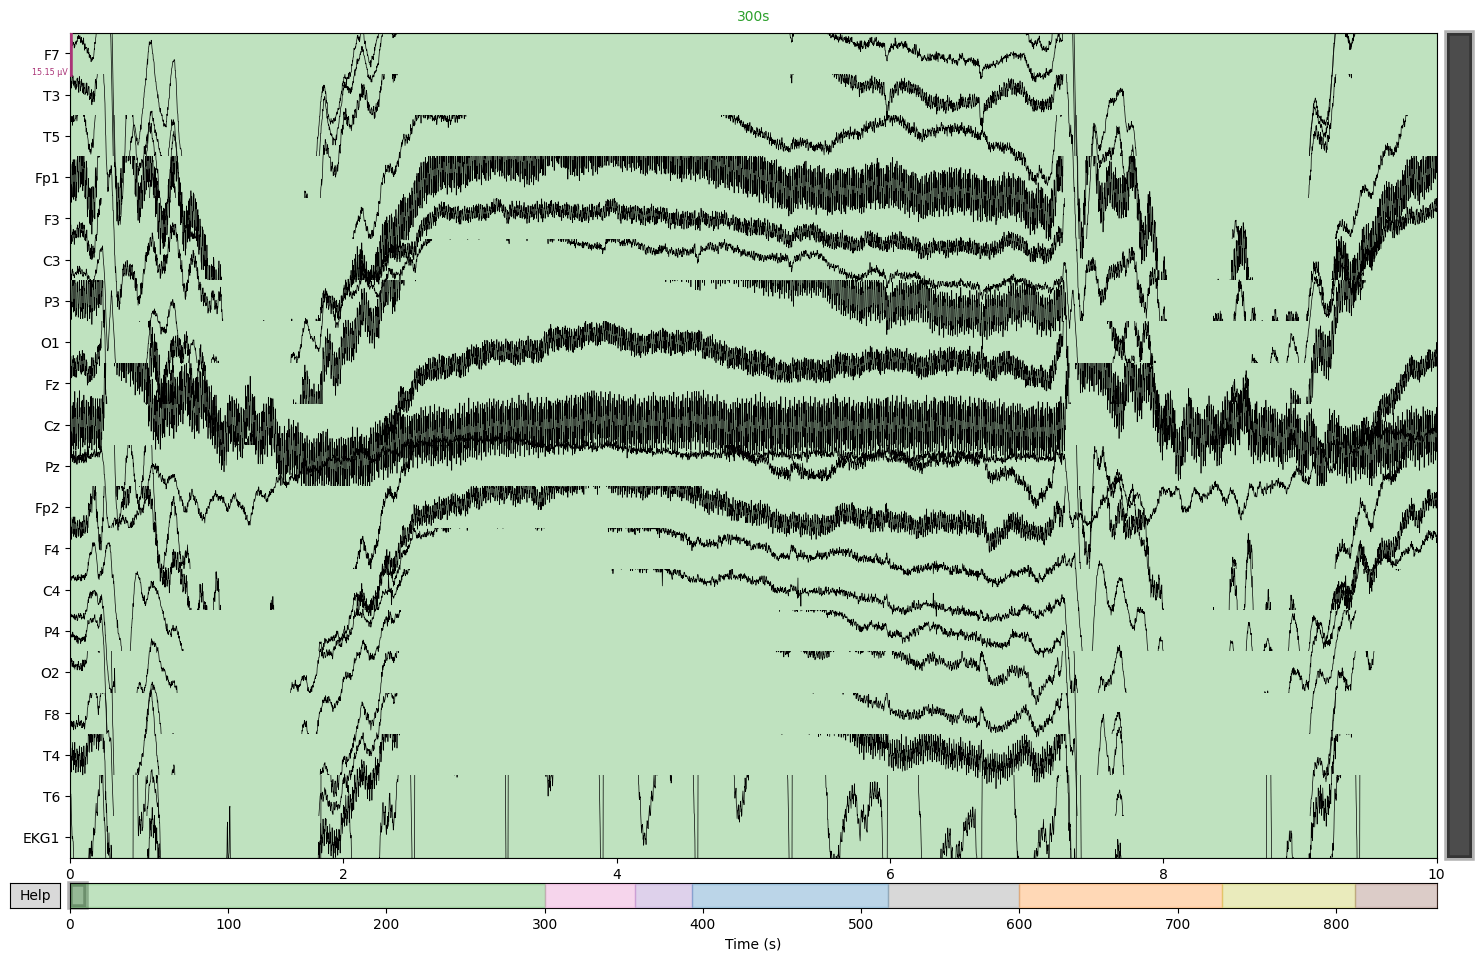

<Annotations | 8 segments: 124s (1), 128s (1), 300s (1), 36s (1), 52s (1), ...>

In [3]:

stage_annotations(raw_eeg_end,time_values,stages_dict,patient,stage_start=1,plot=True)

raw_eeg_end.annotations #check if annotations applied

### Defining the Near Death stages

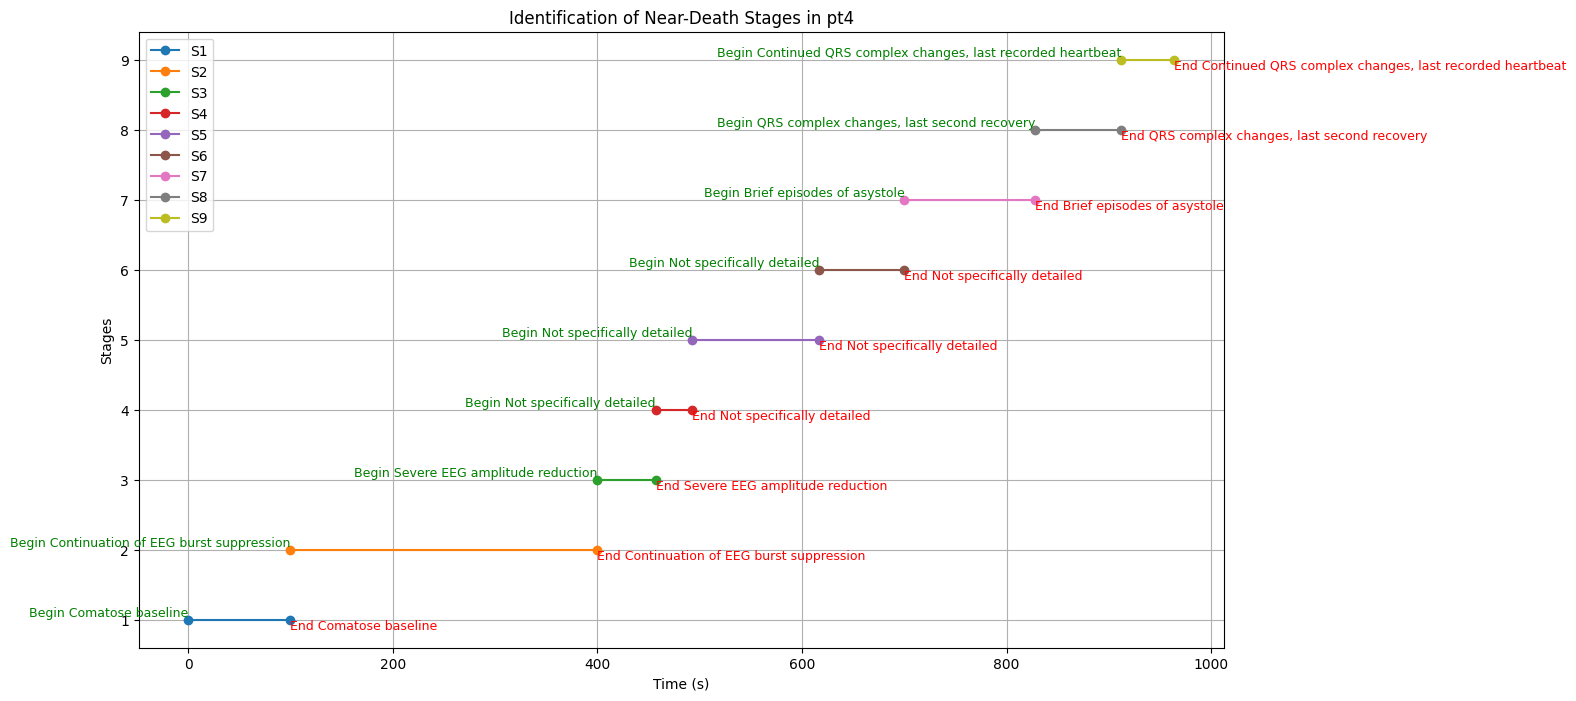

Used Annotations descriptions: ['124s', '128s', '300s', '36s', '52s', '57s', '83s', '84s']


In [4]:
for patient_id in time_values.keys():
    if patient_id == f"pt{patient}": #keep only pt 1 just for visualisation purposes
        plot_patient_stages(patient_id, time_values[patient_id], stage_descriptions[patient_id])
        # stage_annotations(raw_eeg_end, time_values,stage_descriptions, patient,stage_start=1,plot=True)
        mne.events_from_annotations(raw_eeg_end)

### Preprocessing starts 

In [5]:
# ##################### PREPROC PARAMS ####################################################################
baseline_correction = False
epoch_duration = 2.0
detrend = True
normalise = True
save_preproc = True
apply_hilbert = False
apply_ica = False
notch_filter = [60, 120, 180]
downsampling = 250
############################################################################################################

#preprocessing for baseline (Stage 1)
raw_EEG_baseline,raw_ECG_baseline = check_channels(raw_eeg_baseline)
eeg_baseline,epochs_baseline,preproc_params_baseline = raw_preprocess(raw_eeg_baseline,notchf=[60,120,180],downsampling=250,epoch_duration=2,detrend=False,normalise=True,apply_hilbert=False,apply_ica=False,plot_preproc=False)


#preprocessing for end (Stage 2-end)
raw_EEG_end,raw_ECG_end = check_channels(raw_eeg_end)
eeg_end,epochs_end,preproc_params_end = raw_preprocess(raw_eeg_end,notchf=[60,120,180],downsampling=250,epoch_duration=2,detrend=False,normalise=True,apply_hilbert=False,apply_ica=False,plot_preproc=False)


preprocessed_data = [eeg_baseline,epochs_baseline,eeg_end,epochs_end] #save preprocessed data 
preproc_params_list = [preproc_params_baseline, preproc_params_end]


All channels :  ['F7', 'T3', 'T5', 'Fp1', 'F3', 'C3', 'P3', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'EKG1']
Using channel EKG1 to identify heart beats.
Setting up band-pass filter from 5 - 35 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 5.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 4.75 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 35.25 Hz)
- Filter length: 5120 samples (10.000 s)

Number of ECG events detected : 149 (average pulse 89 / min.)
Selected EEG channels :  ['F7', 'T3', 'T5', 'Fp1', 'F3', 'C3', 'P3', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6']
No montage associated yet. Proceeding with renaming and setting new montage.
EEG channel type selected for re-referencing
Addi

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Number of ECG events detected : 586 (average pulse 40 / min.)
Selected EEG channels :  ['F7', 'T3', 'T5', 'Fp1', 'F3', 'C3', 'P3', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6']
No montage associated yet. Proceeding with renaming and setting new montage.
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Average reference projection applied.
<Annotations | 8 segments: 124s (1), 128s (1), 300s (1), 36s (1), 52s (1), ...>
Used Annotations descriptions: ['124s', '128s', '300s', '36s', '52s', '57s', '83s', '84s']
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


1 bad epochs dropped
Created 2-second epochs without baseline correction: <Epochs |  431 events (all good), 0 – 2 s, baseline off, ~31.3 MB, data loaded,
 '1': 431>
Normalization applied.


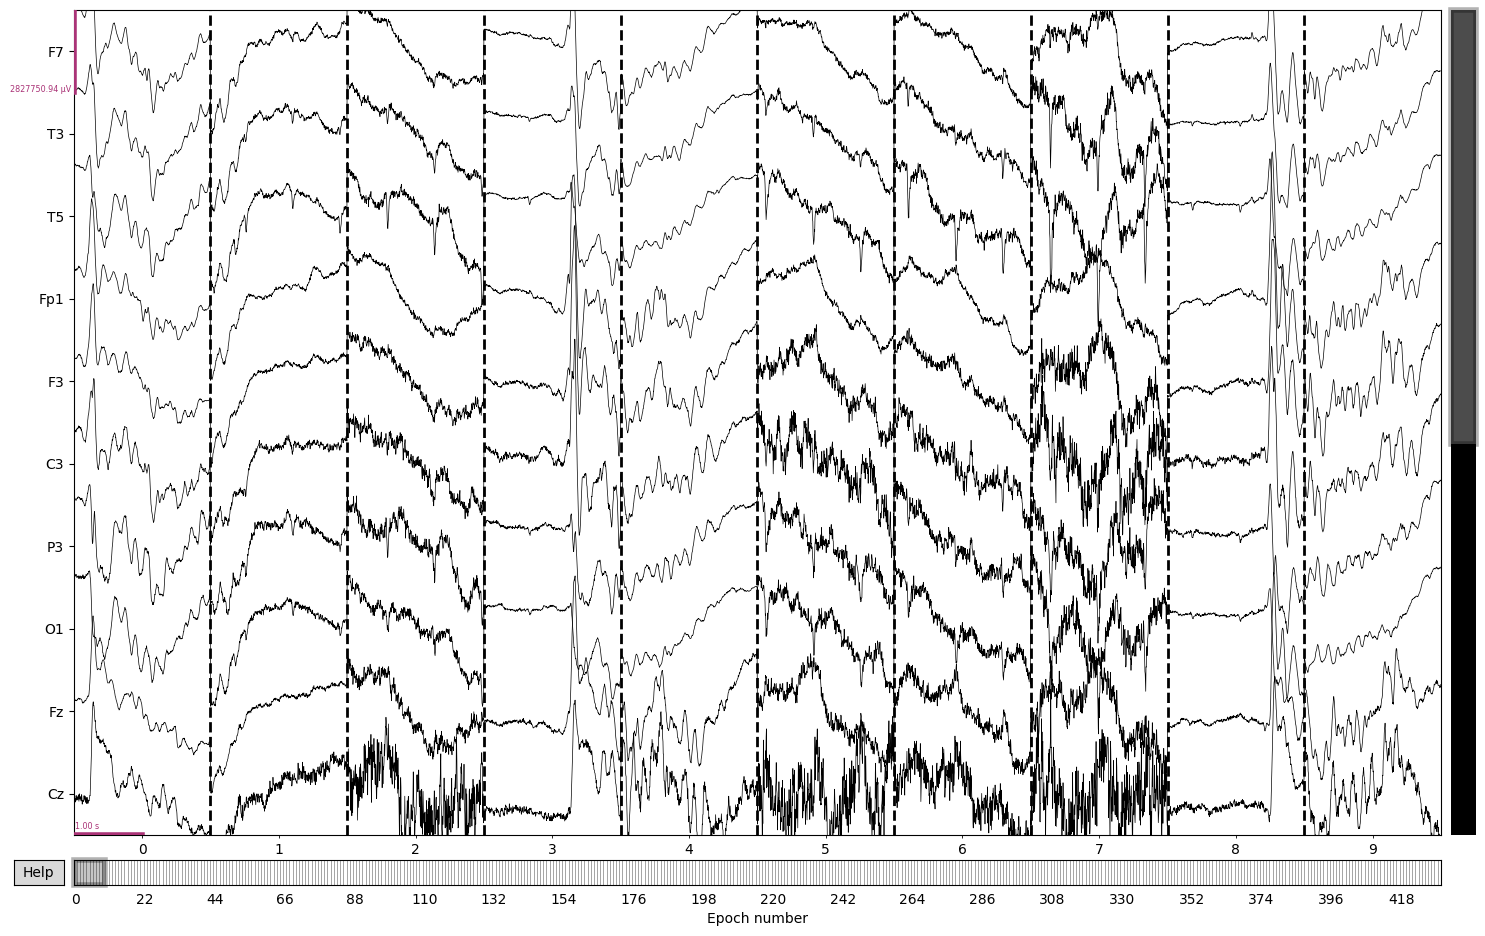

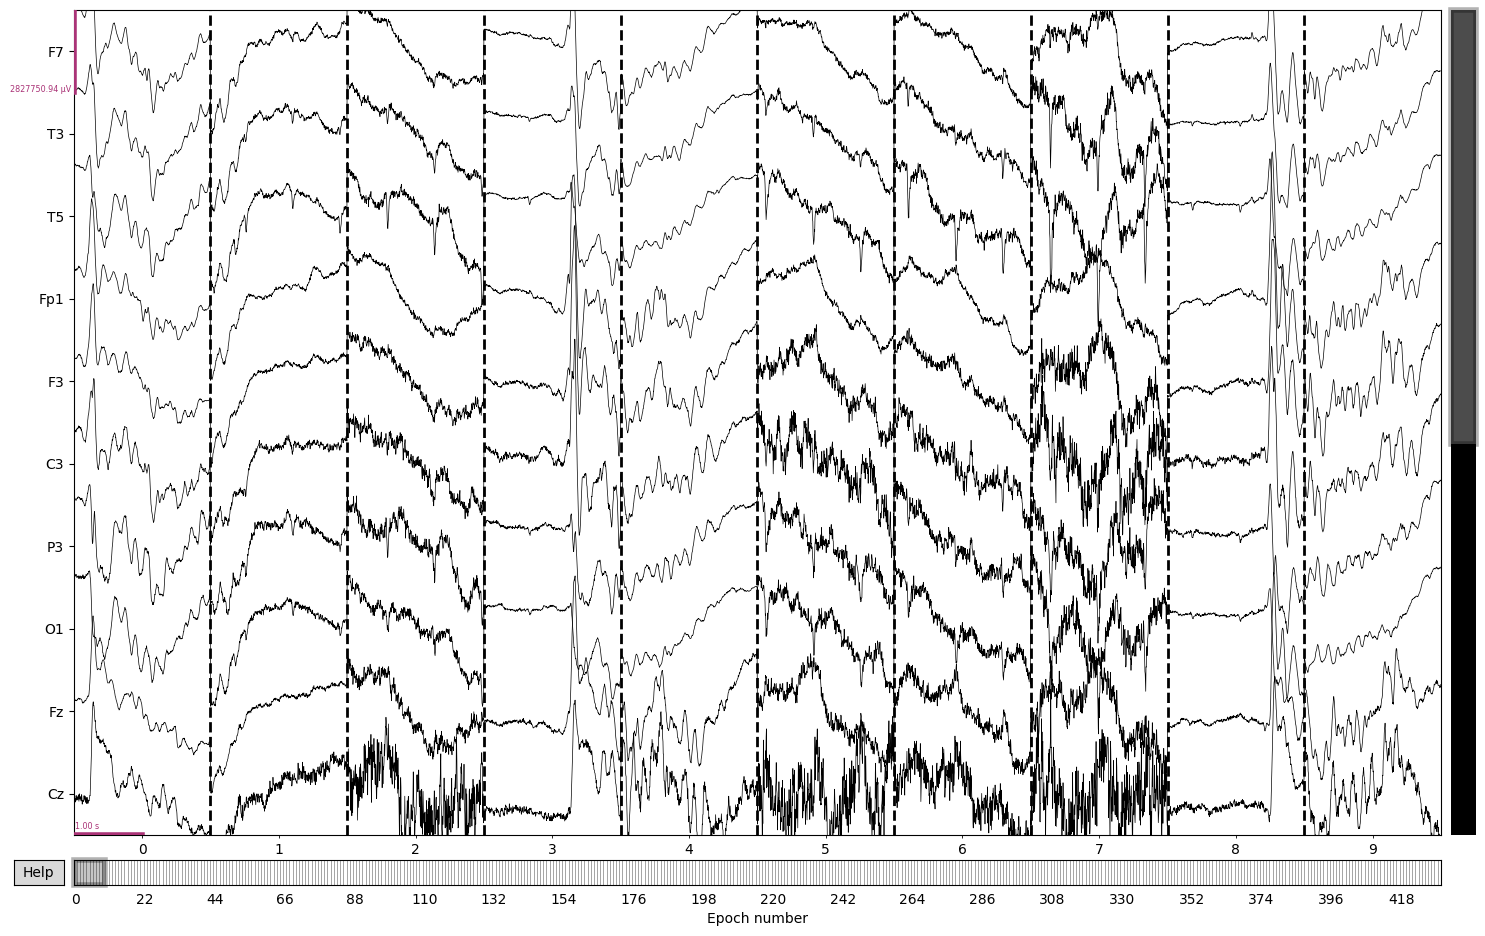

In [6]:

epochs_end.plot(n_epochs=10, n_channels=10, picks='eeg',scalings='auto') #plot the first 10 epochs of the dying stages

In [7]:
epochs_end.annotations[0] #check if annotations applied on epochs

OrderedDict([('onset', 0.0),
             ('duration', 300.0),
             ('description', '300s'),
             ('orig_time',
              datetime.datetime(2018, 6, 19, 9, 27, tzinfo=datetime.timezone.utc))])

In [8]:
#save preprocessing file and parameters of preprocessed_data

if save_preproc:
    save_preprocessed_data(preprocessed_data, preprocessed_folder, EEG_files, preproc_params_list)


Preprocessed data will be saved in the following folder:  /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed
Saving preprocessed data to /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt4_S1_baseline_preprocessed_eeg.fif
Overwriting existing file.
Writing /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt4_S1_baseline_preprocessed_eeg.fif
Closing /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt4_S1_baseline_preprocessed_eeg.fif
[done]
Saving preprocessed data to /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt4_S1_baseline_preprocessed_epo.fif
Overwriting existing file.
Overwriting existing file.
Saving preprocessed data to /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt4_S2-end_end_preprocessed_eeg.fif
Overwriting existing file.
Writing /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt4_S2-end_end_preprocessed_eeg.fif
Closing /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt4_S2-end_end_preprocessed_eeg.fif
[done]
Saving preproces